**REG NO :** 2648525

**Regular lab Question –** I

**Lab Exercise 1:** House Price Prediction Using Multiple Linear Regression on the Boston Housing Dataset

In [5]:
import io
import joblib

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv("boston_housing.csv")
print("=== 1. DATASET OVERVIEW ===")
print("Rows, columns :", df.shape)
print("\nAttribute names and data types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate records:", df.duplicated().sum())
print("\nBasic statistics:\n", df.describe().T.round(3))


=== 1. DATASET OVERVIEW ===
Rows, columns : (506, 14)

Attribute names and data types:
 CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Missing values per column:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Duplicate records: 0

Basic statistics:
          count     mean      std      min      25%      50%      75%      max
CRIM     506.0    3.594    8.597    0.006    0.082    0.257    3.647   88.976
ZN       506.0   11.364   23.322    0.000    0.000    0.000   12.500  100.000
INDUS    506.0   11.137    6.860    0.460    5.190    9.690   18.100   27.740
CHAS     506.0    0.069    0.254    0.000    0.000    


=== 2. EDA ===
MEDV skewness: 1.108 | kurtosis: 1.495
Records with MEDV == 50 (censored at top): 16


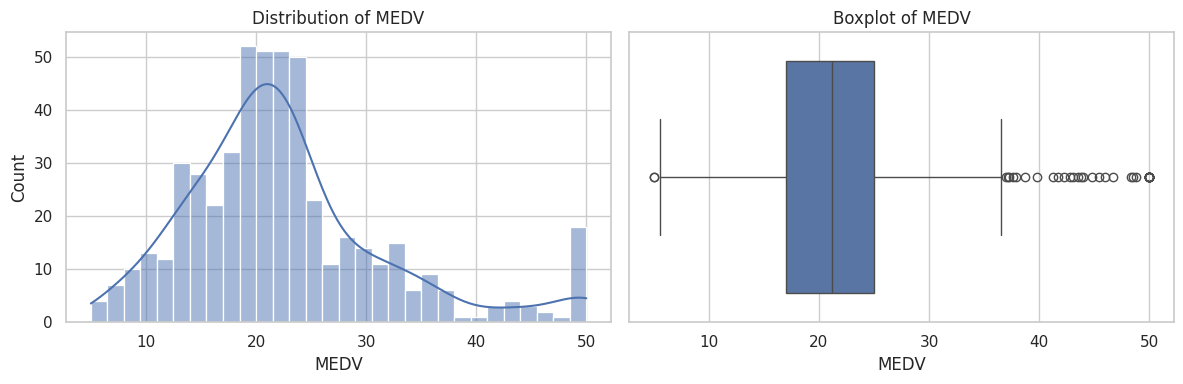


Correlation of each attribute with MEDV:
 LSTAT     -0.738
PTRATIO   -0.508
INDUS     -0.484
TAX       -0.469
NOX       -0.427
CRIM      -0.386
RAD       -0.382
AGE       -0.377
CHAS       0.175
DIS        0.250
B          0.333
ZN         0.360
RM         0.695
Name: MEDV, dtype: float64


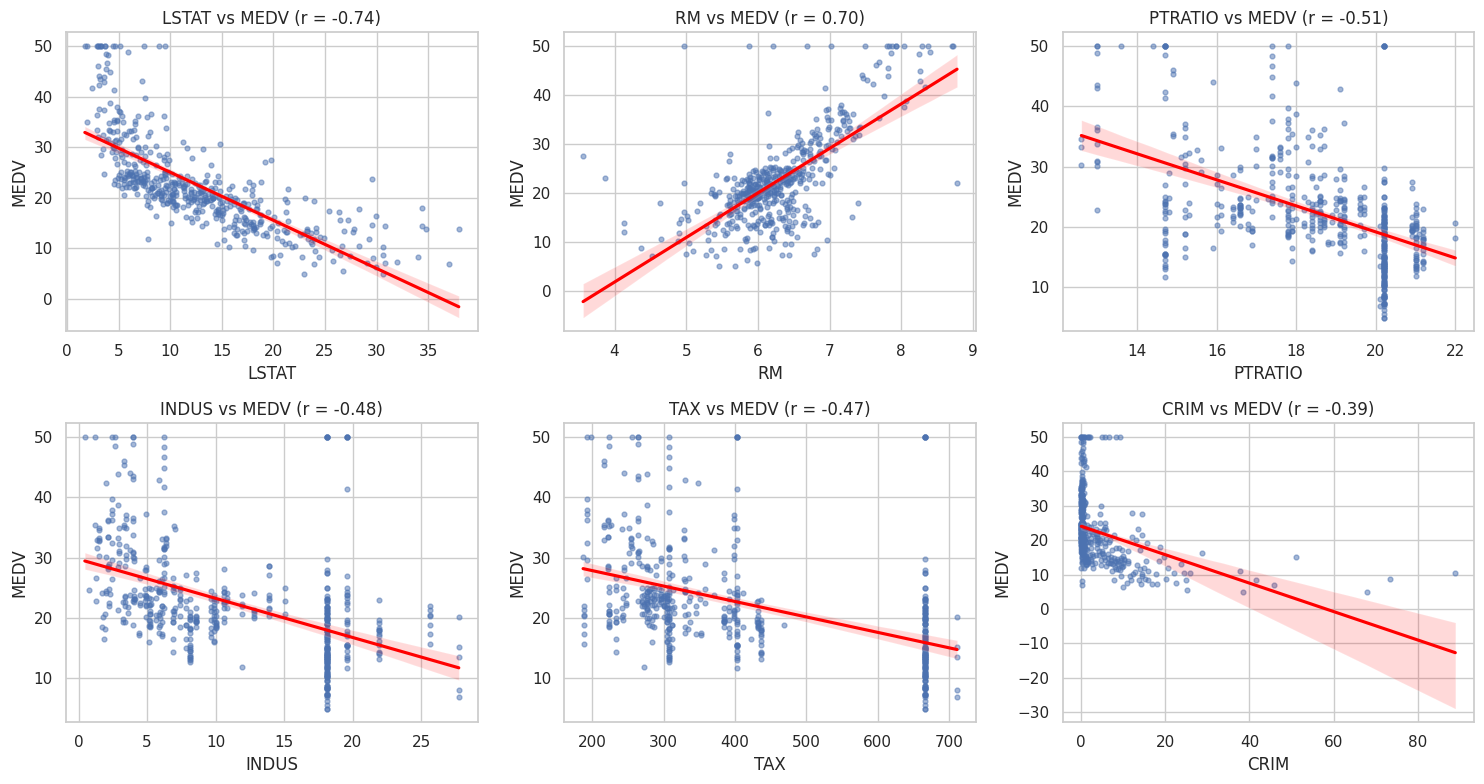

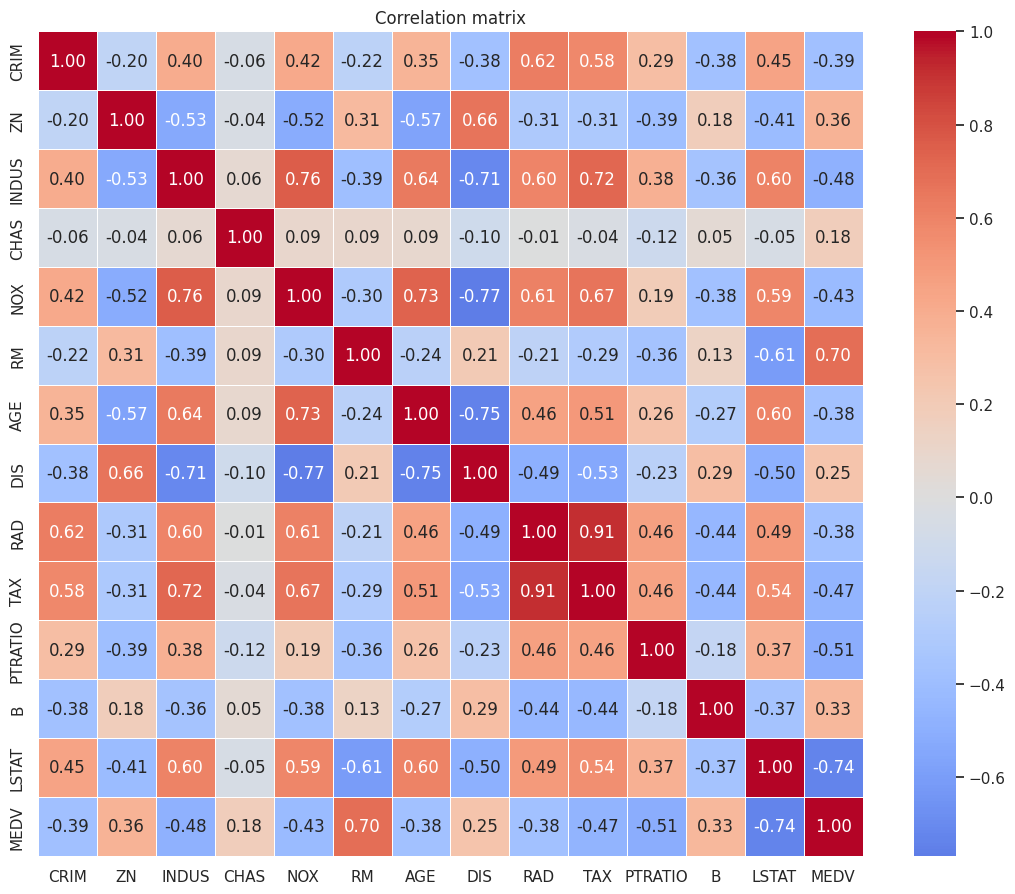


Strong relationships with MEDV (|r| >= 0.5):
 LSTAT     -0.738
PTRATIO   -0.508
RM         0.695
Name: MEDV, dtype: float64

Predictor pairs with |r| >= 0.7 (multicollinearity risk):
  INDUS    - NOX     : 0.764
  INDUS    - DIS     : -0.708
  INDUS    - TAX     : 0.721
  NOX      - AGE     : 0.731
  NOX      - DIS     : -0.769
  AGE      - DIS     : -0.748
  RAD      - TAX     : 0.910


In [7]:
print("\n=== 2. EDA ===")
print("MEDV skewness: %.3f | kurtosis: %.3f" % (df.MEDV.skew(), df.MEDV.kurt()))
print("Records with MEDV == 50 (censored at top):", (df.MEDV == 50).sum())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.MEDV, bins=30, kde=True, ax=ax[0]); ax[0].set_title("Distribution of MEDV")
sns.boxplot(x=df.MEDV, ax=ax[1]); ax[1].set_title("Boxplot of MEDV")
plt.tight_layout(); plt.show()

corr = df.corr()
print("\nCorrelation of each attribute with MEDV:\n", corr["MEDV"].drop("MEDV").sort_values().round(3))

sel = ["LSTAT", "RM", "PTRATIO", "INDUS", "TAX", "CRIM"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for a, c in zip(axes.ravel(), sel):
    sns.regplot(x=df[c], y=df.MEDV, ax=a, scatter_kws={"s": 12, "alpha": .5}, line_kws={"color": "red"})
    a.set_title(f"{c} vs MEDV (r = {corr.loc[c,'MEDV']:.2f})")
plt.tight_layout(); plt.show()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=.5)
plt.title("Correlation matrix"); plt.tight_layout()
plt.show()

strong = corr["MEDV"].drop("MEDV")
print("\nStrong relationships with MEDV (|r| >= 0.5):\n", strong[strong.abs() >= .5].sort_values().round(3))
hi = [(a, b, corr.loc[a, b]) for i, a in enumerate(corr.columns) for b in corr.columns[i+1:]
      if abs(corr.loc[a, b]) >= .7 and "MEDV" not in (a, b)]
print("\nPredictor pairs with |r| >= 0.7 (multicollinearity risk):")
for a, b, r in hi: print(f"  {a:8s} - {b:8s}: {r:.3f}")


In [8]:
X, y = df.drop(columns="MEDV"), df["MEDV"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
print("\n=== 3. DATA PREPARATION ===")
print("Train:", X_tr.shape, " Test:", X_te.shape)
# OLS needs no scaling for its predictions. A scaled copy is fitted later ONLY to compare coefficients.
scaler = StandardScaler().fit(X_tr)


=== 3. DATA PREPARATION ===
Train: (404, 13)  Test: (102, 13)


In [9]:
model = LinearRegression().fit(X_tr, y_tr)
pred_tr, pred_te = model.predict(X_tr), model.predict(X_te)
coef = pd.DataFrame({"Coefficient": model.coef_, "Std. coefficient":
       LinearRegression().fit(scaler.transform(X_tr), y_tr).coef_}, index=X.columns)
print("\n=== 4. MODEL ===")
print("Intercept: %.4f" % model.intercept_)
print(coef.sort_values("Std. coefficient").round(4))


=== 4. MODEL ===
Intercept: 30.2889
         Coefficient  Std. coefficient
LSTAT        -0.5093           -3.6172
DIS          -1.4485           -3.0832
PTRATIO      -0.9164           -2.0398
NOX         -17.2406           -2.0268
TAX          -0.0106           -1.7657
CRIM         -0.1125           -0.9962
AGE          -0.0062           -0.1745
INDUS         0.0407            0.2805
ZN            0.0301            0.6956
CHAS          2.7868            0.7193
B             0.0125            1.1387
RAD           0.2621            2.2487
RM            4.4325            3.1407


In [10]:
def metrics(y_true, y_pred, p):
    n = len(y_true); r2 = r2_score(y_true, y_pred); mse = mean_squared_error(y_true, y_pred)
    return dict(MAE=mean_absolute_error(y_true, y_pred), MSE=mse, RMSE=np.sqrt(mse),
                R2=r2, Adj_R2=1 - (1 - r2) * (n - 1) / (n - p - 1))
res = pd.DataFrame({"Train": metrics(y_tr, pred_tr, X.shape[1]),
                    "Test":  metrics(y_te, pred_te, X.shape[1])})
print("\n=== 5. EVALUATION ===\n", res.round(4))


=== 5. EVALUATION ===
           Train     Test
MAE      3.3152   3.1915
MSE     21.6416  24.3114
RMSE     4.6521   4.9307
R2       0.7509   0.6685
Adj_R2   0.7426   0.6195


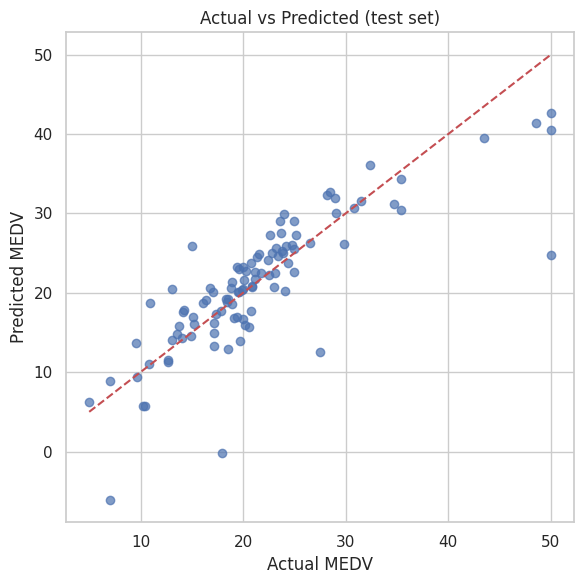

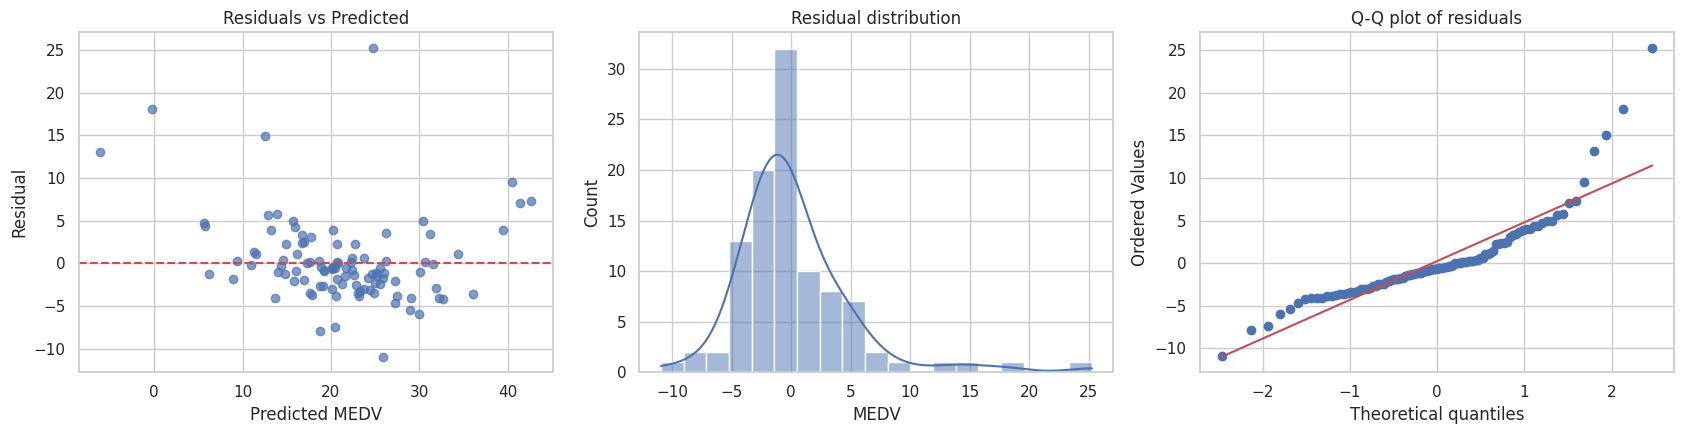

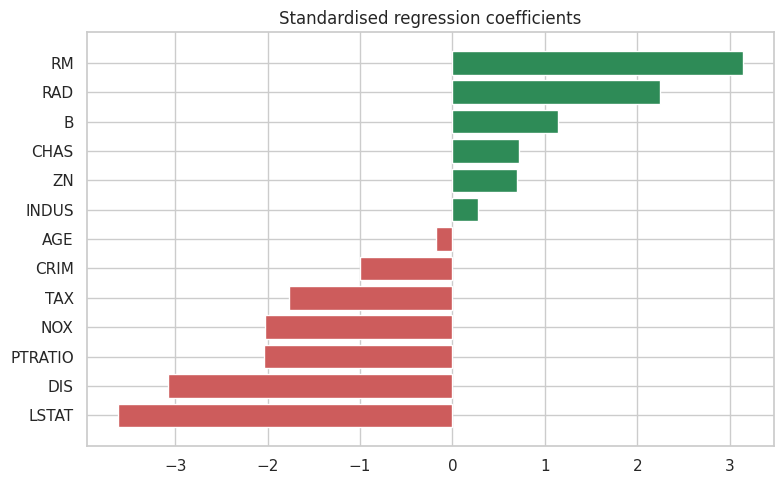


=== 6. RESIDUAL DIAGNOSTICS ===
Residual mean: 0.238 | std: 4.949 | skew: 2.094
Shapiro-Wilk p-value: 2.021e-09
Largest |residuals|:
 371    25.26
412    18.10
365    14.98
414    13.10
375    10.94
Name: MEDV, dtype: float64


In [11]:
lo, hi_ = y.min(), y.max()
plt.figure(figsize=(6, 6))
plt.scatter(y_te, pred_te, alpha=.7); plt.plot([lo, hi_], [lo, hi_], "r--")
plt.xlabel("Actual MEDV"); plt.ylabel("Predicted MEDV"); plt.title("Actual vs Predicted (test set)")
plt.tight_layout(); plt.show()

resid = y_te - pred_te
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].scatter(pred_te, resid, alpha=.7); ax[0].axhline(0, color="r", ls="--")
ax[0].set(xlabel="Predicted MEDV", ylabel="Residual", title="Residuals vs Predicted")
sns.histplot(resid, kde=True, ax=ax[1]); ax[1].set_title("Residual distribution")
stats.probplot(resid, plot=ax[2]); ax[2].set_title("Q-Q plot of residuals")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 5))
c = coef["Std. coefficient"].sort_values()
plt.barh(c.index, c.values, color=np.where(c.values > 0, "seagreen", "indianred"))
plt.title("Standardised regression coefficients"); plt.tight_layout()
plt.show()

print("\n=== 6. RESIDUAL DIAGNOSTICS ===")
print("Residual mean: %.3f | std: %.3f | skew: %.3f" % (resid.mean(), resid.std(), resid.skew()))
print("Shapiro-Wilk p-value: %.4g" % stats.shapiro(resid)[1])
print("Largest |residuals|:\n", resid.abs().sort_values(ascending=False).head(5).round(2))


In [12]:
Xs = scaler.transform(X_tr)
vif = pd.Series([1 / (1 - r2_score(Xs[:, j], LinearRegression().fit(np.delete(Xs, j, 1), Xs[:, j])
      .predict(np.delete(Xs, j, 1)))) for j in range(Xs.shape[1])], index=X.columns)
print("\n=== 7. VIF ===\n", vif.sort_values(ascending=False).round(2))

# Improvement experiments (illustrative)
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
cv = KFold(5, shuffle=True, random_state=42)
def cv_r2(m, Xd, yd): return cross_val_score(m, Xd, yd, cv=cv, scoring="r2").mean()
print("\n5-fold CV R2  baseline OLS          : %.4f" % cv_r2(LinearRegression(), X, y))
print("5-fold CV R2  Ridge(alpha=10)        : %.4f" % cv_r2(make_pipeline(StandardScaler(), Ridge(10)), X, y))
print("5-fold CV R2  log(MEDV) target       : %.4f" % cv_r2(LinearRegression(), X, np.log(y)))
X2 = X.assign(LSTAT2=X.LSTAT**2, LOGLSTAT=np.log(X.LSTAT), RM2=X.RM**2)
print("5-fold CV R2  + LSTAT^2, log(LSTAT), RM^2: %.4f" % cv_r2(LinearRegression(), X2, y))
X3 = X.drop(columns=["INDUS", "AGE"])
print("5-fold CV R2  drop INDUS, AGE        : %.4f" % cv_r2(LinearRegression(), X3, y))
print("5-fold CV R2  baseline OLS (again, full features) confirms stability across folds:",
      cross_val_score(LinearRegression(), X, y, cv=cv, scoring="r2").round(3))



=== 7. VIF ===
 TAX        8.94
RAD        7.65
NOX        4.47
DIS        4.17
INDUS      3.88
AGE        2.99
LSTAT      2.82
ZN         2.47
RM         1.95
PTRATIO    1.85
CRIM       1.69
B          1.32
CHAS       1.10
dtype: float64

5-fold CV R2  baseline OLS          : 0.7151
5-fold CV R2  Ridge(alpha=10)        : 0.7144
5-fold CV R2  log(MEDV) target       : 0.7668
5-fold CV R2  + LSTAT^2, log(LSTAT), RM^2: 0.8006
5-fold CV R2  drop INDUS, AGE        : 0.7177
5-fold CV R2  baseline OLS (again, full features) confirms stability across folds: [0.668 0.734 0.71  0.776 0.687]


In [13]:
print("\n" + "=" * 70 + "\n=== 8. INTERPRETATION OF RESULTS ===\n" + "=" * 70)

print("\n--- A. Regression coefficients (MEDV is in $1000s; other variables held constant) ---")
for f, b in coef["Coefficient"].sort_values(key=abs, ascending=False).items():
    direction = "raises" if b > 0 else "lowers"
    print(f"  {f:8s} {b:+9.4f} : +1 unit in {f} {direction} predicted MEDV by about ${abs(b)*1000:,.0f}")
print(f"  Intercept {model.intercept_:.2f} : predicted MEDV when every predictor is 0 (not meaningful on its own).")
sc = coef["Std. coefficient"].sort_values()
print("  Largest negative effects (standardised):", ", ".join(sc.index[:3]))
print("  Largest positive effects (standardised):", ", ".join(sc.index[::-1][:3]))
print("  Note: raw coefficients depend on units (NOX looks huge only because it ranges 0.39-0.87);")
print("  use the standardised column to compare importance.")
print("  RAD and TAX are highly correlated (see VIF), so their individual signs are unreliable.")

print("\n--- B. Meaning of R-squared ---")
print(f"  Test R2 = {res.loc['R2','Test']:.3f}: the model explains about {res.loc['R2','Test']*100:.0f}% of the variation in "
      "median house value across neighbourhoods.")
print(f"  Typical error: MAE = ${res.loc['MAE','Test']*1000:,.0f}, RMSE = ${res.loc['RMSE','Test']*1000:,.0f} "
      f"on homes averaging ${y.mean()*1000:,.0f}.")
print("  Good for area-level screening; not precise enough to value an individual home.")

print("\n--- C. Actual vs Predicted and residuals ---")
print("  Points near the red diagonal are accurate. The residuals form a U-shape: the model UNDER-predicts")
print("  both cheap areas (predictions < 15) and expensive areas (actual >= 40), and OVER-predicts the middle range.")
print(f"  It even predicts {(pred_te < 5).sum()} negative/near-zero prices (min = {pred_te.min():.1f}), which is impossible.")
print(f"  Residual skew = {resid.skew():.2f} and Shapiro-Wilk p = {stats.shapiro(resid)[1]:.1e}: residuals are not normal,")
print("  and the curved residual pattern shows the true relationships are partly non-linear.")

print("\n--- D. Underfitting / overfitting ---")
gap = res.loc["R2", "Train"] - res.loc["R2", "Test"]
print(f"  Train R2 = {res.loc['R2','Train']:.3f}, Test R2 = {res.loc['R2','Test']:.3f} (gap = {gap:.3f}).")
if res.loc["R2", "Train"] < 0.8:
    print("  Training R2 is itself only moderate -> mild UNDERFITTING (model too simple for the non-linear data).")
if gap > 0.15:
    print("  Large train/test gap -> some overfitting as well.")
else:
    print("  The train/test gap is modest -> no serious overfitting.")

print("\n--- E. Strengths of the model ---")
for s in ["Simple, fast and easy to explain to non-technical stakeholders.",
          "Coefficients show direction and size of each attribute's effect.",
          "Solid baseline: MAE about $3,200, R2 about 0.67-0.72 (cross-validated).",
          "Stable across folds and no serious overfitting; needs little tuning."]:
    print("  +", s)

print("\n--- F. Limitations of the model ---")
for l in ["Assumes linear relationships; residual plots show curvature (e.g. LSTAT, RM).",
          "Multicollinearity (RAD-TAX, NOX-DIS-INDUS) makes some coefficients unreliable.",
          "Sensitive to outliers and to the 16 capped MEDV = 50 records; large errors on expensive areas.",
          "Residuals are non-normal and not constant-variance, so confidence intervals would be unreliable.",
          "Uses area-level data from the 1970s; the variable B is ethically questionable and should not be used in real systems.",
          "Correlation, not causation: coefficients describe association only."]:
    print("  -", l)

print("\n--- G. Ways to improve ---")
print("  Polynomial/log terms for LSTAT and RM, log-transform MEDV, treat outliers/capped values,")
print("  regularisation (Ridge/Lasso), interaction terms, and non-linear models (Random Forest, Gradient Boosting).")



=== 8. INTERPRETATION OF RESULTS ===

--- A. Regression coefficients (MEDV is in $1000s; other variables held constant) ---
  NOX       -17.2406 : +1 unit in NOX lowers predicted MEDV by about $17,241
  RM         +4.4325 : +1 unit in RM raises predicted MEDV by about $4,432
  CHAS       +2.7868 : +1 unit in CHAS raises predicted MEDV by about $2,787
  DIS        -1.4485 : +1 unit in DIS lowers predicted MEDV by about $1,448
  PTRATIO    -0.9164 : +1 unit in PTRATIO lowers predicted MEDV by about $916
  LSTAT      -0.5093 : +1 unit in LSTAT lowers predicted MEDV by about $509
  RAD        +0.2621 : +1 unit in RAD raises predicted MEDV by about $262
  CRIM       -0.1125 : +1 unit in CRIM lowers predicted MEDV by about $112
  INDUS      +0.0407 : +1 unit in INDUS raises predicted MEDV by about $41
  ZN         +0.0301 : +1 unit in ZN raises predicted MEDV by about $30
  B          +0.0125 : +1 unit in B raises predicted MEDV by about $12
  TAX        -0.0106 : +1 unit in TAX lowers pred